# Intraday Scanner Candidates v0.1 - Run Inspection

Notebook de inspeccion visual para `intraday_scanner_candidates_table_v0_1`.

Uso: cambia `RUN_ROOT` si quieres inspeccionar otro replay. El notebook no es autoridad productiva; la autoridad vive en contratos, builder, runner, manifests y tests.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

REPO_ROOT = Path(r'C:/TSIS_Data')
DEFAULT_RUN_ROOT = REPO_ROOT / 'tests' / 'test_runs' / '2026-06-30' / 'intraday_scanner_candidates_replay_20250102_20250110_v0_1'

# Cambia aqui para inspeccionar otro run.
RUN_ROOT = DEFAULT_RUN_ROOT

def read_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8-sig'))

print('RUN_ROOT:', RUN_ROOT)
print('exists:', RUN_ROOT.exists())

RUN_ROOT: C:\TSIS_Data\tests\test_runs\2026-06-30\intraday_scanner_candidates_replay_20250102_20250110_v0_1
exists: True


In [2]:
summary_path = RUN_ROOT / '_run_summary.json'
heartbeat_paths = sorted(RUN_ROOT.glob('*.heartbeat.json'))
pre_manifest_paths = sorted(RUN_ROOT.glob('*.pre_manifest.json'))
part_manifests = sorted(RUN_ROOT.glob('parts/**/_intraday_scanner_candidates_table_manifest_v0_1_candidate_replay.json'))
parquet_paths = sorted(RUN_ROOT.glob('parts/**/intraday_scanner_candidates_table_v0_1_candidate_replay/data.parquet'))

print('run_summary:', summary_path)
print('pre_manifests:', len(pre_manifest_paths))
print('heartbeats:', len(heartbeat_paths))
print('part_manifests:', len(part_manifests))
print('parquet_parts:', len(parquet_paths))

run_summary = read_json(summary_path) if summary_path.exists() else None
display(pd.DataFrame([run_summary]) if run_summary else 'No run summary found')

if part_manifests:
    manifests = [read_json(p) for p in part_manifests]
    display(pd.DataFrame([m.get('stats', {}) | {'manifest_path': str(p)} for m, p in zip(manifests, part_manifests)]))

run_summary: C:\TSIS_Data\tests\test_runs\2026-06-30\intraday_scanner_candidates_replay_20250102_20250110_v0_1\_run_summary.json
pre_manifests: 3
heartbeats: 3
part_manifests: 1
parquet_parts: 1


,run_id,status,completed_at_utc,run_root,start_date,end_date,window_count,parts_root,full_universe_claim,materialization_scope,note
0,intraday_scanner_candidates_v0_1_20260630T175311Z,completed,2026-06-30T17:55:31.1718847Z,C:\TSIS_Data\tests\test_runs\2026-06-30\intrad...,2025-01-02,2025-01-10,1,C:\TSIS_Data\tests\test_runs\2026-06-30\intrad...,False,candidate_replay_month_parts,Monthly parts are authoritative for this runne...


,base_eligible_rows,duplicate_ticker_session_keys,first_cross_afterhours_rows,first_cross_premarket_rows,first_cross_regular_rows,full_universe_claim,materialization_scope,max_selected_first_cross_move_pct,min_selected_first_cross_move_pct,motion_threshold_rows,rows,selected_intraday_in_play_candidate_rows,session_dates,source_ohlcv_1m_file_count,tickers,tradability_pass_rows,manifest_path
0,7498,0,39,114,82,False,candidate_replay,164.389831,50.0,235,33413,102,6,5775,5690,176,C:\TSIS_Data\tests\test_runs\2026-06-30\intrad...


In [3]:
assert parquet_paths, 'No parquet parts found. Check RUN_ROOT.'
df = pd.concat([pd.read_parquet(p) for p in parquet_paths], ignore_index=True)
df['session_date'] = pd.to_datetime(df['session_date']).dt.date
df['first_cross_50_ts_utc'] = pd.to_datetime(df['first_cross_50_ts_utc'], errors='coerce', utc=True)
df['as_of_utc'] = pd.to_datetime(df['as_of_utc'], errors='coerce', utc=True)

print('rows:', len(df))
print('tickers:', df['ticker'].nunique())
print('sessions:', df['session_date'].nunique())
display(df.head(20))

rows: 33413
tickers: 5690
sessions: 6


,intraday_scanner_candidate_id,scanner_run_id,created_at_utc,dataset_id,schema_version,quality_policy_version,scanner_policy_version,scanner_definition_id,base_scanner_definition_id,materialization_scope,full_universe_claim,instrument_id,ticker,session_date,as_of_utc,as_of_policy,instrument_name,primary_exchange,exchange_acronym,active_in_reference,reference_last_updated_utc,common_stock_filter_passed,market_cap_usd,market_cap_filter_passed,shares_outstanding_context,float_shares,float_unavailable_reason,prior_close,daily_open,daily_high,daily_low,daily_close,daily_volume,daily_dollar_volume,rvol_20d,gap_pct,daily_return_pct,family_data_quality_verdict,data_present,backtest_core_row_candidate,expected_session,expected_reason,first_bar_ts_utc,last_bar_ts_utc,extended_bar_count,extended_volume,extended_dollar_volume,max_move_vs_prev_close_pct,max_move_vs_segment_open_pct,premarket_high_vs_prev_close_pct,regular_high_vs_prev_close_pct,afterhours_high_vs_prev_close_pct,max_move_segment,first_cross_50_ts_utc,first_cross_50_ts_et,first_cross_50_segment,first_cross_price,first_cross_move_vs_prev_close_pct,first_cross_move_vs_segment_open_pct,volume_to_time_at_first_cross,dollar_volume_to_time_at_first_cross,bars_observed_to_first_cross,first_cross_source_ohlcv_1m_file,motion_threshold_passed,tradability_threshold_passed,price_filter_passed_at_first_cross,base_eligible_smallcap_denominator_passed,selected_intraday_in_play_candidate,scanner_selection_state,candidate_reasons,source_ohlcv_1m_root,source_master_daily_root,source_master_daily_manifest,source_instrument_master_manifest,source_market_calendar_manifest,master_daily_build_run_id
0,717f9c0b6a7927f63849c535ca550507,intraday_scanner_candidates_v0_1_20260630T1753...,2026-06-30T17:53:12Z,intraday_scanner_candidates_table_v0_1,intraday_scanner_candidates_table_v0_1,intraday_scanner_candidates_policy_v0_1,intraday_scanner_framework_v0_1,intraday_in_play_momentum_candidate_denominato...,base_eligible_smallcap_denominator_v0_3,candidate_replay,False,figi_share_class:BBG001V0YJ76,GPRO,2025-01-10,2025-01-11 00:43:00+00:00,first_cross_when_selected_else_last_extended_b...,"GoPro, Inc.",XNAS,NaN,True,2026-03-05T07:07:10.59194999Z,True,1.168432e+08,False,159728275.0,NaN,float_context_table_not_materialized_point_in_...,1.100,1.095,1.1000,1.06,1.080,1741637.0,1.880968e+06,1.157867,-0.004545,-0.018182,usable_for_declared_scope,True,True,True,calendar_session_present,2025-01-10 12:35:00+00:00,2025-01-11 00:43:00+00:00,383,1.648392e+06,1.772520e+06,2.654545,2.654545,2.654545,0.000000,-0.909091,premarket,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,None,False,False,evaluated_not_base_eligible,,E:/TSIS/data/ohlcv_1m,E:/TSIS/data/data_foundation_outputs/master_da...,E:/TSIS/data/data_foundation_outputs/master_da...,E:/TSIS/data/data_foundation_outputs/instrumen...,E:/TSIS/data/data_foundation_outputs/market_ca...,master_daily_table_v0_1_20260622T161747Z
1,db3a29197c425f896e6a34080e70f624,intraday_scanner_candidates_v0_1_20260630T1753...,2026-06-30T17:53:12Z,intraday_scanner_candidates_table_v0_1,intraday_scanner_candidates_table_v0_1,intraday_scanner_candidates_policy_v0_1,intraday_scanner_framework_v0_1,intraday_in_play_momentum_candidate_denominato...,base_eligible_smallcap_denominator_v0_3,candidate_replay,False,NaN,GRC,2025-01-07,2025-01-07 21:01:00+00:00,first_cross_when_selected_else_last_extended_b...,NaN,NaN,NaN,False,NaN,False,NaN,None,NaN,NaN,float_context_table_not_materialized_point_in_...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,calendar_session_present,2025-01-07 09:00:00+00:00,2025-01-07 21:01:00+00:00,84,5.387300e+04,1.996164e+06,NaN,5.464481,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,None,False,False,evaluated_not_base_eligible,,E:/TSIS/data/ohlcv_1m,E:/TSIS/data/data_foundation_outputs/master_da...,E:/TSIS/data/data_foundation_outputs/master_da...,E:/TSIS/data/data_foundation_outputs/instrumen...,E:/TSIS/data/data_foundation_out

In [4]:
kpis = {
    'rows': len(df),
    'tickers': df['ticker'].nunique(),
    'sessions': df['session_date'].nunique(),
    'base_eligible_rows': int(df['base_eligible_smallcap_denominator_passed'].sum()),
    'motion_threshold_rows': int(df['motion_threshold_passed'].sum()),
    'tradability_pass_rows': int(df['tradability_threshold_passed'].sum()),
    'selected_intraday_in_play_candidate_rows': int(df['selected_intraday_in_play_candidate'].sum()),
    'duplicate_ticker_session_keys': int(df.groupby(['ticker', 'session_date']).size().gt(1).sum()),
}
display(pd.DataFrame(kpis.items(), columns=['metric', 'value']))

,metric,value
0,rows,33413
1,tickers,5690
2,sessions,6
3,base_eligible_rows,7498
4,motion_threshold_rows,235
5,tradability_pass_rows,176
6,selected_intraday_in_play_candidate_rows,102
7,duplicate_ticker_session_keys,0


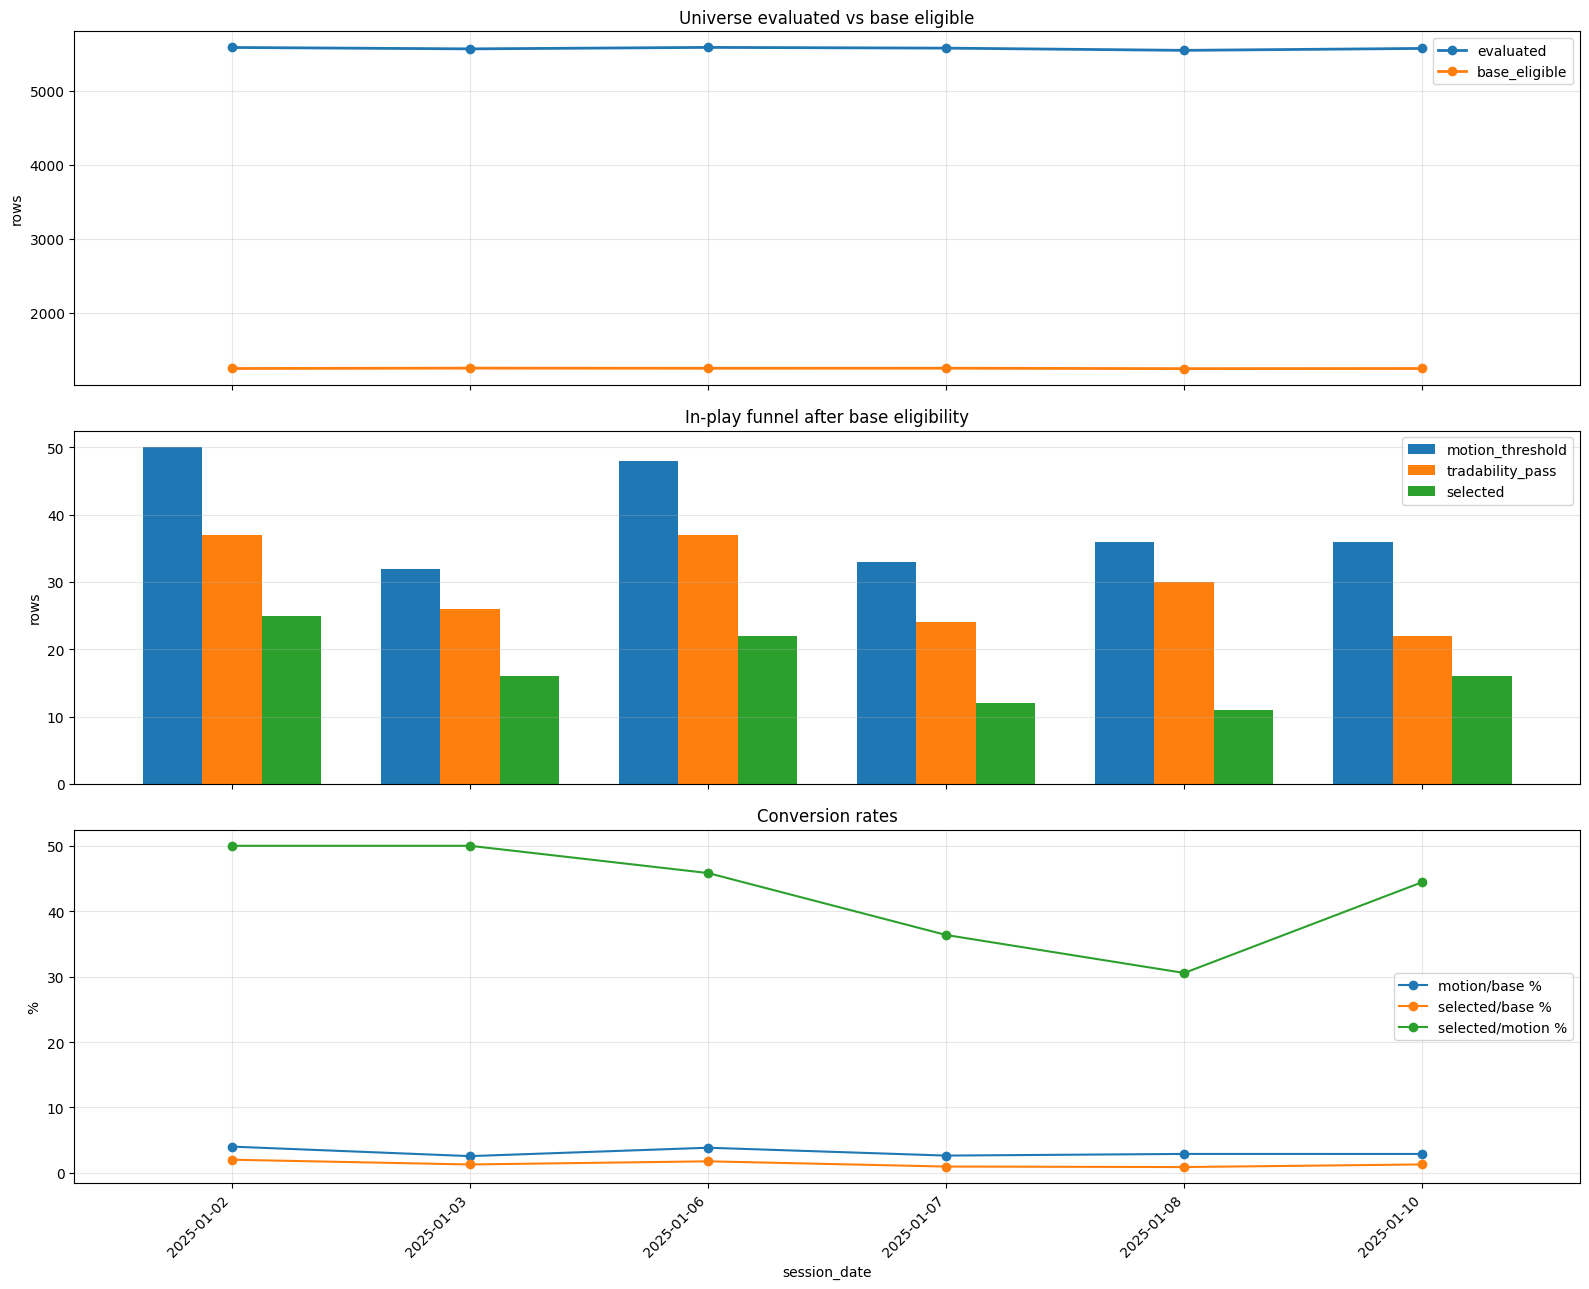

,session_date,evaluated,base_eligible,motion_threshold,tradability_pass,selected,selected_rate_vs_base_pct,motion_rate_vs_base_pct,selected_rate_vs_motion_pct
0,2025-01-02,5582,1248,50,37,25,2.003205,4.006410,50.000000
1,2025-01-03,5563,1253,32,26,16,1.276935,2.553871,50.000000
2,2025-01-06,5583,1251,48,37,22,1.758593,3.836930,45.833333
3,2025-01-07,5573,1252,33,24,12,0.958466,2.635783,36.363636
4,2025-01-08,5543,1246,36,30,11,0.882825,2.889246,30.555556
5,2025-01-10,5569,1248,36,22,16,1.282051,2.884615,44.444444


In [5]:
daily = (
    df.groupby('session_date')
      .agg(
          evaluated=('ticker', 'size'),
          base_eligible=('base_eligible_smallcap_denominator_passed', 'sum'),
          motion_threshold=('motion_threshold_passed', 'sum'),
          tradability_pass=('tradability_threshold_passed', 'sum'),
          selected=('selected_intraday_in_play_candidate', 'sum'),
      )
      .reset_index()
)

daily['selected_rate_vs_base_pct'] = (daily['selected'] / daily['base_eligible'].replace(0, pd.NA) * 100).astype('float')
daily['motion_rate_vs_base_pct'] = (daily['motion_threshold'] / daily['base_eligible'].replace(0, pd.NA) * 100).astype('float')
daily['selected_rate_vs_motion_pct'] = (daily['selected'] / daily['motion_threshold'].replace(0, pd.NA) * 100).astype('float')

x = list(range(len(daily)))
labels = [str(v) for v in daily['session_date']]

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

# Panel 1: universo grande. Separado para que no aplaste las series pequenas.
axes[0].plot(x, daily['evaluated'], marker='o', linewidth=2, label='evaluated')
axes[0].plot(x, daily['base_eligible'], marker='o', linewidth=2, label='base_eligible')
axes[0].set_title('Universe evaluated vs base eligible')
axes[0].set_ylabel('rows')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel 2: funnel operativo. Aqui se ven las diferencias relevantes.
width = 0.25
axes[1].bar([i - width for i in x], daily['motion_threshold'], width=width, label='motion_threshold')
axes[1].bar(x, daily['tradability_pass'], width=width, label='tradability_pass')
axes[1].bar([i + width for i in x], daily['selected'], width=width, label='selected')
axes[1].set_title('In-play funnel after base eligibility')
axes[1].set_ylabel('rows')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend()

# Panel 3: ratios. Muestra si el dia fue mas selectivo aunque los conteos sean pequenos.
axes[2].plot(x, daily['motion_rate_vs_base_pct'], marker='o', label='motion/base %')
axes[2].plot(x, daily['selected_rate_vs_base_pct'], marker='o', label='selected/base %')
axes[2].plot(x, daily['selected_rate_vs_motion_pct'], marker='o', label='selected/motion %')
axes[2].set_title('Conversion rates')
axes[2].set_ylabel('%')
axes[2].set_xlabel('session_date')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(daily)

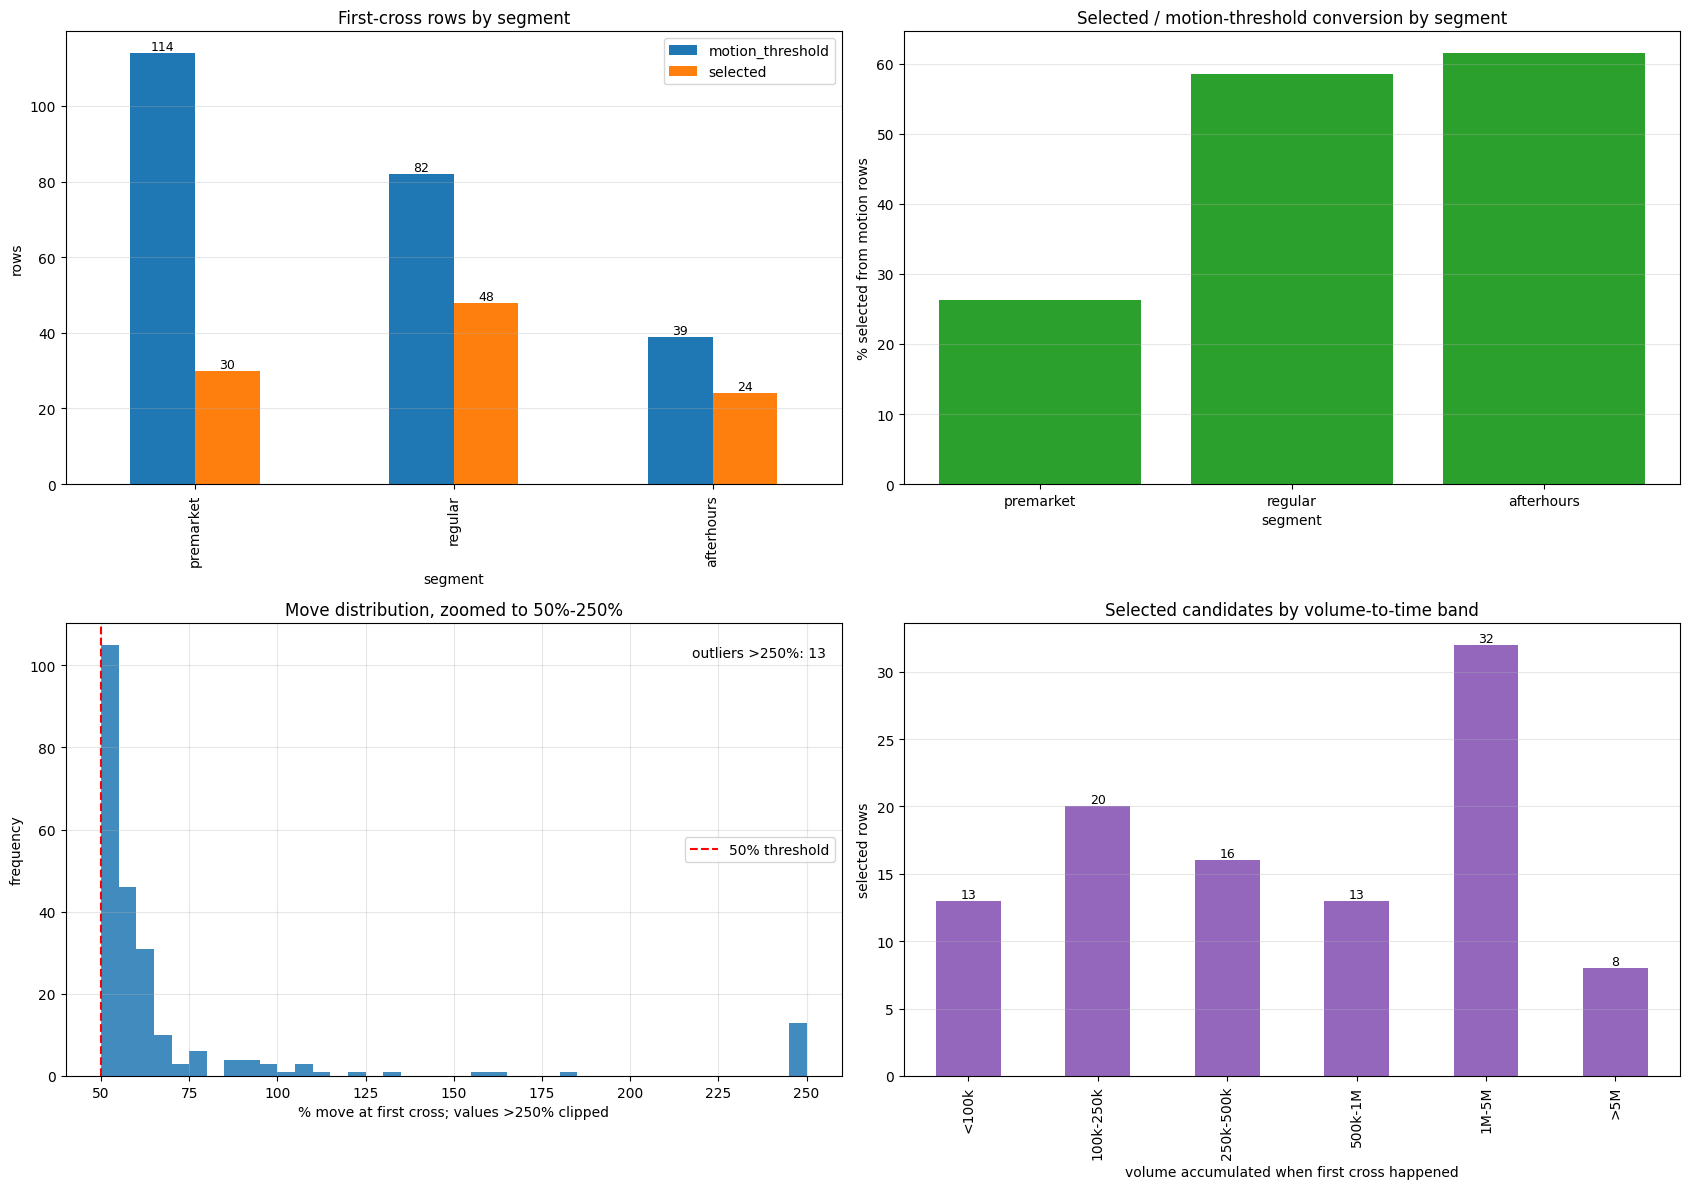

,motion_threshold,selected,selection_rate_pct
first_cross_50_segment,,,
premarket,114,30,26.315789
regular,82,48,58.536585
afterhours,39,24,61.538462


In [6]:
motion = df[df['motion_threshold_passed']].copy()
selected = df[df['selected_intraday_in_play_candidate']].copy()

segment_order = ['premarket', 'regular', 'afterhours']
seg_all = motion['first_cross_50_segment'].value_counts().reindex(segment_order, fill_value=0)
seg_selected = selected['first_cross_50_segment'].value_counts().reindex(segment_order, fill_value=0)
seg_compare = pd.DataFrame({'motion_threshold': seg_all, 'selected': seg_selected})
seg_compare['selection_rate_pct'] = (seg_compare['selected'] / seg_compare['motion_threshold'].replace(0, pd.NA) * 100).astype('float')

fig, axes = plt.subplots(2, 2, figsize=(17, 12))

seg_compare[['motion_threshold', 'selected']].plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('First-cross rows by segment')
axes[0, 0].set_xlabel('segment')
axes[0, 0].set_ylabel('rows')
axes[0, 0].grid(True, axis='y', alpha=0.3)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fontsize=9)

axes[0, 1].bar(seg_compare.index, seg_compare['selection_rate_pct'].fillna(0), color='tab:green')
axes[0, 1].set_title('Selected / motion-threshold conversion by segment')
axes[0, 1].set_xlabel('segment')
axes[0, 1].set_ylabel('% selected from motion rows')
axes[0, 1].grid(True, axis='y', alpha=0.3)

move_cap = 250
move_values = motion['first_cross_move_vs_prev_close_pct'].dropna()
move_zoom = move_values.clip(upper=move_cap)
outlier_moves = int((move_values > move_cap).sum())
axes[1, 0].hist(move_zoom, bins=40, color='tab:blue', alpha=0.85)
axes[1, 0].axvline(50, color='red', linestyle='--', label='50% threshold')
axes[1, 0].set_title('Move distribution, zoomed to 50%-250%')
axes[1, 0].set_xlabel('% move at first cross; values >250% clipped')
axes[1, 0].set_ylabel('frequency')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].text(0.98, 0.95, f'outliers >250%: {outlier_moves}', transform=axes[1, 0].transAxes, ha='right', va='top')

vol_bins = [0, 100_000, 250_000, 500_000, 1_000_000, 5_000_000, float('inf')]
vol_labels = ['<100k', '100k-250k', '250k-500k', '500k-1M', '1M-5M', '>5M']
vol_tiers = pd.cut(selected['volume_to_time_at_first_cross'], bins=vol_bins, labels=vol_labels, include_lowest=True)
vol_counts = vol_tiers.value_counts().reindex(vol_labels, fill_value=0)
vol_counts.plot(kind='bar', ax=axes[1, 1], color='tab:purple')
axes[1, 1].set_title('Selected candidates by volume-to-time band')
axes[1, 1].set_xlabel('volume accumulated when first cross happened')
axes[1, 1].set_ylabel('selected rows')
axes[1, 1].grid(True, axis='y', alpha=0.3)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

display(seg_compare)

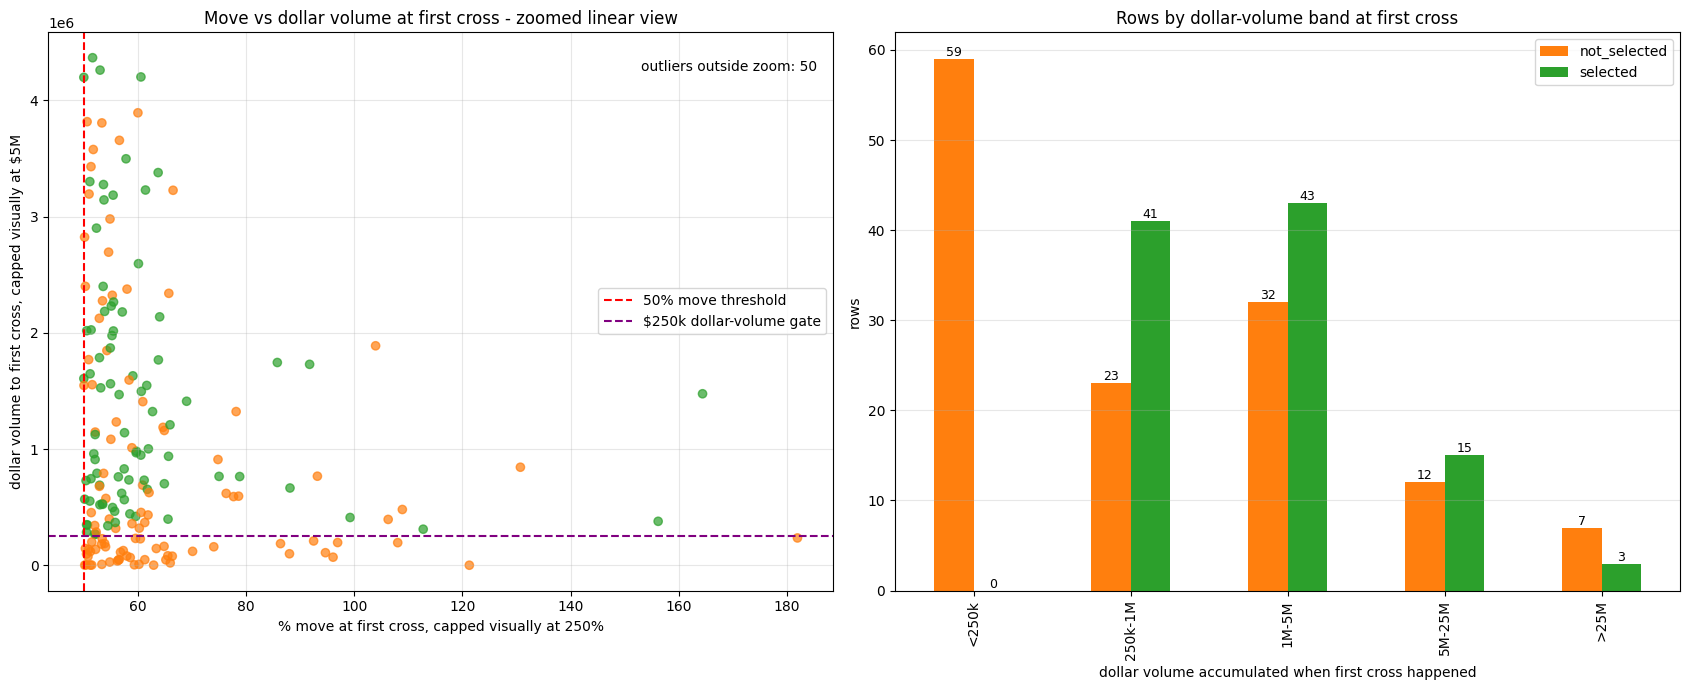

,ticker,session_date,selected_intraday_in_play_candidate,first_cross_50_segment,first_cross_move_vs_prev_close_pct,dollar_volume_to_time_at_first_cross,volume_to_time_at_first_cross,first_cross_price,prior_close,scanner_selection_state
16522,DTCK,2025-01-06,False,premarket,2377.064220,1.453858e+05,5.857750e+03,27.0000,1.0900,motion_threshold_seen_not_selected
24947,RVPH,2025-01-08,False,premarket,2080.000000,4.490800e+02,1.030000e+01,43.6000,2.0000,motion_threshold_seen_not_selected
10226,DTCK,2025-01-10,False,regular,1997.087379,1.371600e+02,6.350000e+00,21.6000,1.0300,motion_threshold_seen_not_selected
33370,RVPH,2025-01-06,False,premarket,1973.684211,1.377002e+03,3.500000e+01,39.4000,1.9000,motion_threshold_seen_not_selected
33379,DTCK,2025-01-02,False,regular,1973.334613,4.153032e+02,1.930000e+01,21.6000,1.0418,motion_threshold_seen_not_selected
20677,RVPH,2025-01-07,False,premarket,1950.761421,6.464000e+02,1.600000e+01,40.4000,1.9700,motion_threshold_seen_not_selected
27086,RVPH,2025-01-03,False,premarket,1919.900498,4.060000e+02,1.000000e+01,40.6000,2.0100,motion_threshold_seen_not_selected
20684,DTCK,2025-01-03,False,regular,1900.000000,3.080000e+02,1.400000e+01,22.0000,1.1000,motion_threshold_seen_not_selected
31323,DTCK,2025-01-08,False,premarket,1900.000000,2.150700e+02,1.005000e+01,21.4000,1.0700,motion_threshold_seen_not_selected
16518,RVPH,2025-01-02,False,premarket,1888.950276,6.480000e+02,1.800000e+01,36.0000,1.8100,motion_threshold_seen_not_selected


In [ ]:
plot_df = motion.dropna(subset=['first_cross_move_vs_prev_close_pct', 'dollar_volume_to_time_at_first_cross']).copy()

move_zoom_cap = 250
dollar_zoom_cap = 5_000_000
zoom_df = plot_df[
    (plot_df['first_cross_move_vs_prev_close_pct'] <= move_zoom_cap) &
    (plot_df['dollar_volume_to_time_at_first_cross'] <= dollar_zoom_cap)
].copy()
outlier_df = plot_df.drop(zoom_df.index).copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

colors = zoom_df['selected_intraday_in_play_candidate'].map({True: 'tab:green', False: 'tab:orange'})
axes[0].scatter(
    zoom_df['first_cross_move_vs_prev_close_pct'],
    zoom_df['dollar_volume_to_time_at_first_cross'],
    c=colors,
    alpha=0.7,
)
axes[0].axvline(50, color='red', linestyle='--', label='50% move threshold')
axes[0].axhline(250_000, color='purple', linestyle='--', label='$250k dollar-volume gate')
axes[0].set_title('Move vs dollar volume at first cross - zoomed linear view')
axes[0].set_xlabel('% move at first cross, capped visually at 250%')
axes[0].set_ylabel('dollar volume to first cross, capped visually at $5M')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].text(0.98, 0.95, f'outliers outside zoom: {len(outlier_df)}', transform=axes[0].transAxes, ha='right', va='top')

dollar_bins = [0, 250_000, 1_000_000, 5_000_000, 25_000_000, float('inf')]
dollar_labels = ['<250k', '250k-1M', '1M-5M', '5M-25M', '>25M']
plot_df['dollar_volume_tier'] = pd.cut(plot_df['dollar_volume_to_time_at_first_cross'], bins=dollar_bins, labels=dollar_labels, include_lowest=True)
tier_table = pd.crosstab(plot_df['dollar_volume_tier'], plot_df['selected_intraday_in_play_candidate']).reindex(dollar_labels, fill_value=0)
tier_table.columns = ['not_selected', 'selected'] if len(tier_table.columns) == 2 else [str(c) for c in tier_table.columns]
tier_table.plot(kind='bar', ax=axes[1], color=['tab:orange', 'tab:green'])
axes[1].set_title('Rows by dollar-volume band at first cross')
axes[1].set_xlabel('dollar volume accumulated when first cross happened')
axes[1].set_ylabel('rows')
axes[1].grid(True, axis='y', alpha=0.3)
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

outlier_cols = [
    'ticker', 'session_date', 'selected_intraday_in_play_candidate',
    'first_cross_50_segment', 'first_cross_move_vs_prev_close_pct',
    'dollar_volume_to_time_at_first_cross', 'volume_to_time_at_first_cross',
    'first_cross_price', 'prior_close', 'scanner_selection_state'
]
display(outlier_df.sort_values(['first_cross_move_vs_prev_close_pct', 'dollar_volume_to_time_at_first_cross'], ascending=False)[outlier_cols].head(30))

In [8]:
cols = [
    'ticker', 'session_date', 'selected_intraday_in_play_candidate',
    'first_cross_50_ts_utc', 'first_cross_50_segment',
    'first_cross_move_vs_prev_close_pct', 'first_cross_move_vs_segment_open_pct',
    'volume_to_time_at_first_cross', 'dollar_volume_to_time_at_first_cross',
    'market_cap_usd', 'prior_close', 'first_cross_price',
    'scanner_selection_state', 'candidate_reasons'
]
top = selected.sort_values('first_cross_move_vs_prev_close_pct', ascending=False)[cols].head(50)
display(top)

,ticker,session_date,selected_intraday_in_play_candidate,first_cross_50_ts_utc,first_cross_50_segment,first_cross_move_vs_prev_close_pct,first_cross_move_vs_segment_open_pct,volume_to_time_at_first_cross,dollar_volume_to_time_at_first_cross,market_cap_usd,prior_close,first_cross_price,scanner_selection_state,candidate_reasons
29150,AIFF,2025-01-10,True,2025-01-10 13:01:00+00:00,premarket,164.389831,133.692884,2.761100e+05,1.475531e+06,1.309966e+07,2.3600,6.2396,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
27088,MEGL,2025-01-06,True,2025-01-06 09:00:00+00:00,premarket,156.182174,52.979921,9.007725e+04,3.780002e+05,7.545434e+06,2.2484,5.7600,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
16533,AEI,2025-01-02,True,2025-01-02 09:00:00+00:00,premarket,112.745098,24.712644,1.530370e+05,3.102519e+05,1.431443e+07,1.0200,2.1700,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
27089,MFI,2025-01-03,True,2025-01-03 09:09:00+00:00,premarket,99.230558,45.000000,4.412275e+04,4.107949e+05,5.868532e+07,5.8224,11.6000,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
27095,SILO,2025-01-08,True,2025-01-08 13:29:00+00:00,premarket,91.743119,81.739130,9.609530e+05,1.728784e+06,1.138908e+06,1.0900,2.0900,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
24952,GDTC,2025-01-06,True,2025-01-06 12:02:00+00:00,premarket,88.115942,85.959885,1.204750e+05,6.646307e+05,2.540652e+07,3.4500,6.4900,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
24959,XPON,2025-01-02,True,2025-01-02 13:30:00+00:00,premarket,85.774059,74.117647,4.851560e+05,1.744509e+06,1.008602e+05,2.3900,4.4400,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
27092,RHE,2025-01-10,True,2025-01-10 21:17:00+00:00,afterhours,78.813559,88.392857,2.535150e+05,7.632647e+05,5.223708e+06,2.3600,4.2200,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_afte...
10214,MSAI,2025-01-06,True,2025-01-06 21:07:00+00:00,afterhours,75.000000,70.740036,3.036130e+05,7.645056e+05,6.031724e+06,2.0000,3.5000,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_afte...
14394,MSAI,2025-01-07,True,2025-01-07 09:11:00+00:00,premarket,69.000000,16.551724,4.711180e+05,1.411075e+06,6.031724e+06,2.0000,3.3800,selected_intraday_in_play,move_vs_prev_close_pct_gte_50|first_cross_prem...
